In [7]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.1)

In [8]:
n_states, start_width, delta, measurement_prob,  I, J = 7, 1, 1, 0.8, 1, 1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [9]:
mu, sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100

intensity_matrix_markov = dd._buildK(n_states, mu, sigma)
intensity_matrix_quantum = qd._buildH(n_states, mu, sigma)


In [10]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")

In [11]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    for t in range(1,31):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in range(1,31):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
        

In [12]:
intensity_matrix_markov

Array([[[[-1.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1., -1.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  1., -1.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  1., -1.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  1., -1.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  1., -1.,  1.],
         [ 0.,  0.,  0.,  0.,  0.,  1., -1.]]]], dtype=float64)

In [13]:
intensity_matrix_quantum

Array([[[[0.+3.j, 0.-1.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-1.j, 0.+2.j, 0.-1.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-1.j, 0.+1.j, 0.-1.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-1.j, 0.-0.j, 0.-1.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j, 0.-1.j, 0.-1.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j, 0.-2.j, 0.-1.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j, 0.-3.j]]]],      dtype=complex128)

In [14]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov).squeeze())

,0,1,2,3,4,5,6
0,0.367879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.367879,0.367879,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.183940,0.367879,0.367879,0.000000,0.000000,0.000000,0.000000
3,0.061313,0.183940,0.367879,0.367879,0.000000,0.000000,0.000000
4,0.015328,0.061313,0.183940,0.367879,0.367879,0.000000,0.000000
5,0.003140,0.015848,0.064453,0.199788,0.432332,0.567668,0.432332
6,0.000520,0.003140,0.015848,0.064453,0.199788,0.432332,0.567668


In [15]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot

,states,prior,time,value
0,-3,Upper,0,0.000000e+00
1,-2,Upper,0,0.000000e+00
2,-1,Upper,0,0.000000e+00
3,0,Upper,0,0.000000e+00
4,1,Upper,0,0.000000e+00
...,...,...,...,...
625,-1,Lower,29,4.210930e-11
626,0,Lower,29,4.210930e-10
627,1,Lower,29,3.158198e-09
628,2,Lower,29,5.000000e-01


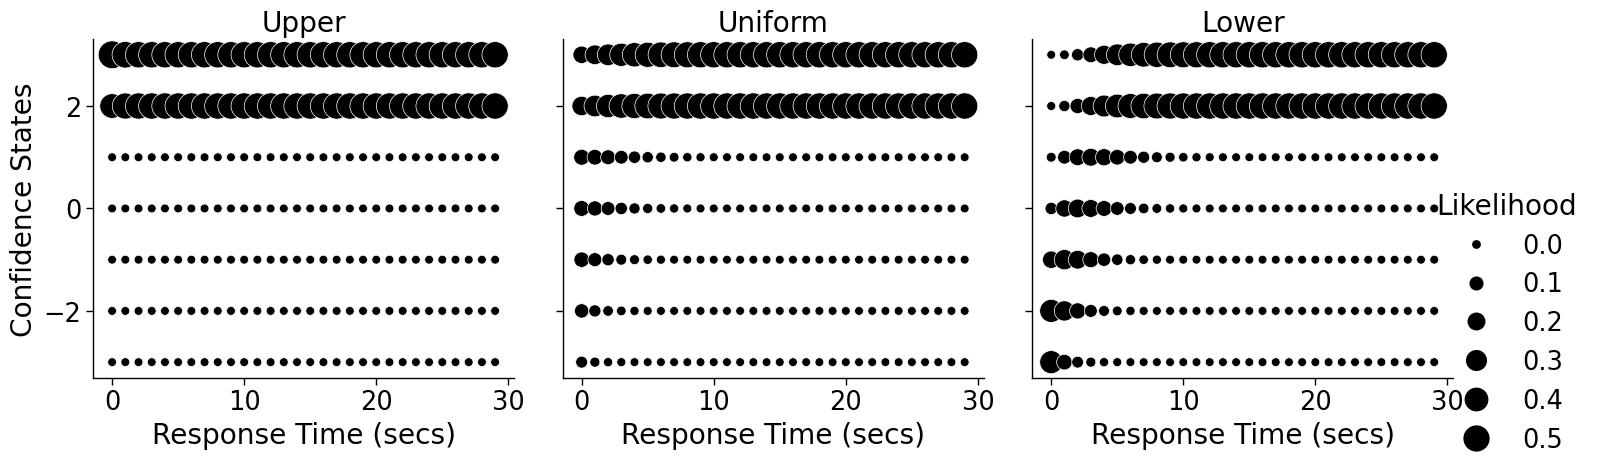

In [16]:
f = sns.relplot(df_markov_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1)
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_bbox_to_anchor((0.9,0.5))
f.legend.set_loc("lower right")

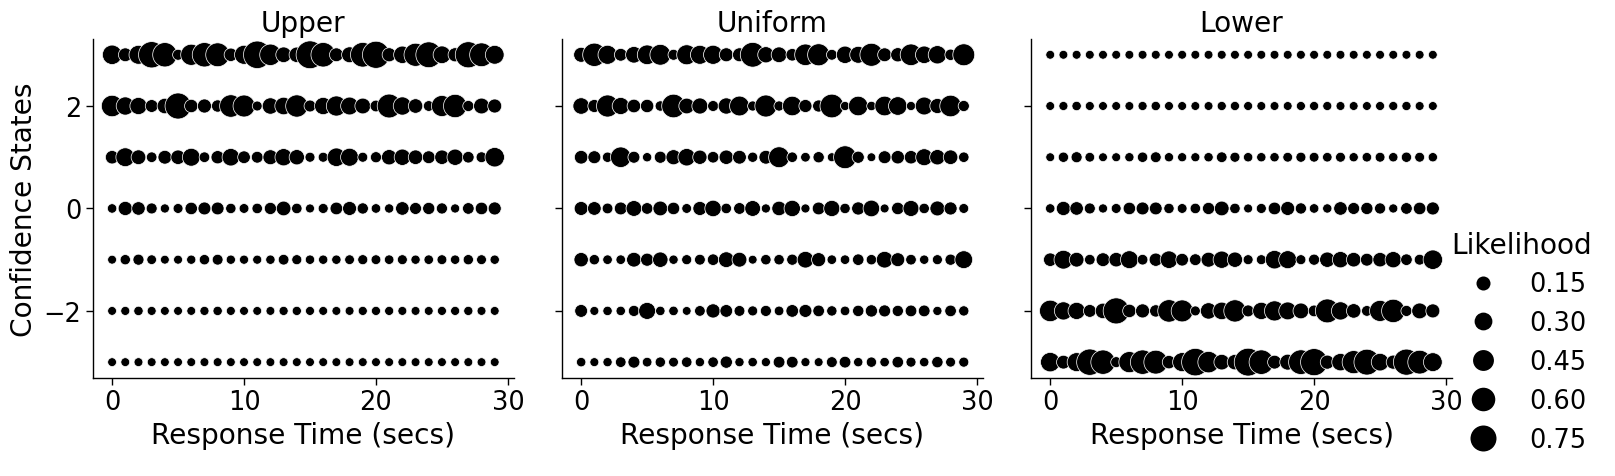

In [17]:
f = sns.relplot(df_quantum_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black")
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
f.legend.set_loc("lower right")

In [18]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [19]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.5]]), npx.asarray([[1]]), npx.asarray([[2]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, (mu+sigma)**(1/2))
    intensity_matrix_quantum = qd._buildH(n_states, mu, sigma)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []
        for t in range(1,31):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in range(1,31):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=np.asarray(mu[0,0]))])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=np.asarray(mu[0,0]))])
        

In [20]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time")
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time")
df_markov1_plot.query("value > 3")

,prior,mu,time,value


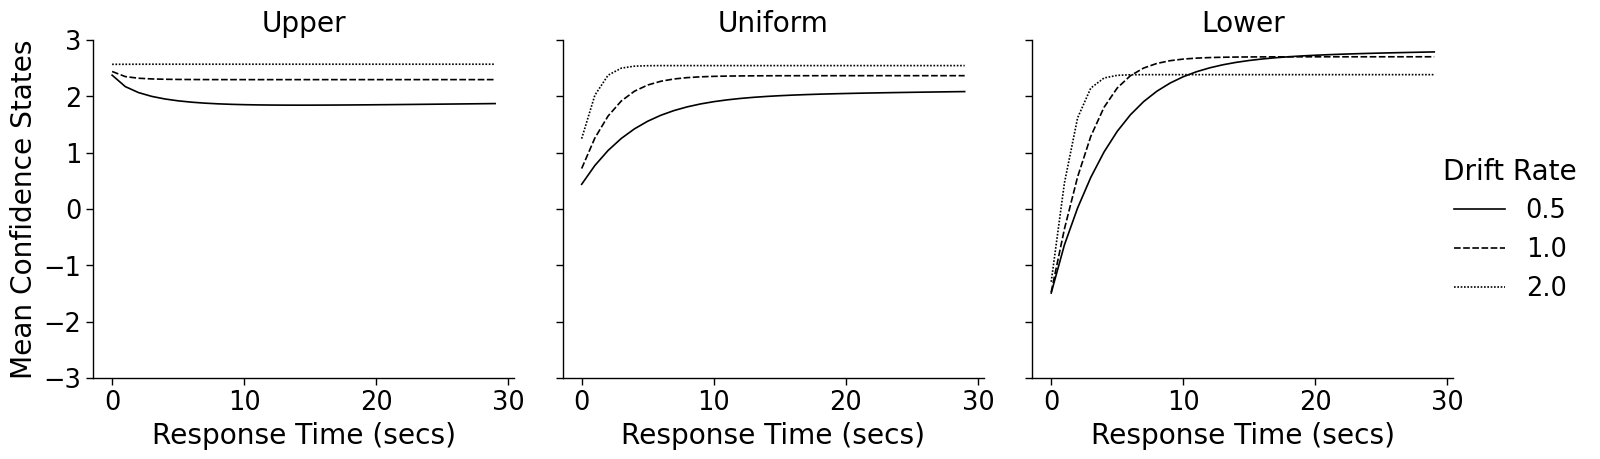

In [23]:
f = sns.relplot(df_markov1_plot,
x="time", y="value", col="prior", style="mu", kind="line", color="Black", facet_kws={"ylim":(-(n_states//2), (n_states//2))})
f.legend.set_title("Drift Rate")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Mean Confidence States")
f.set_titles("{col_name}")

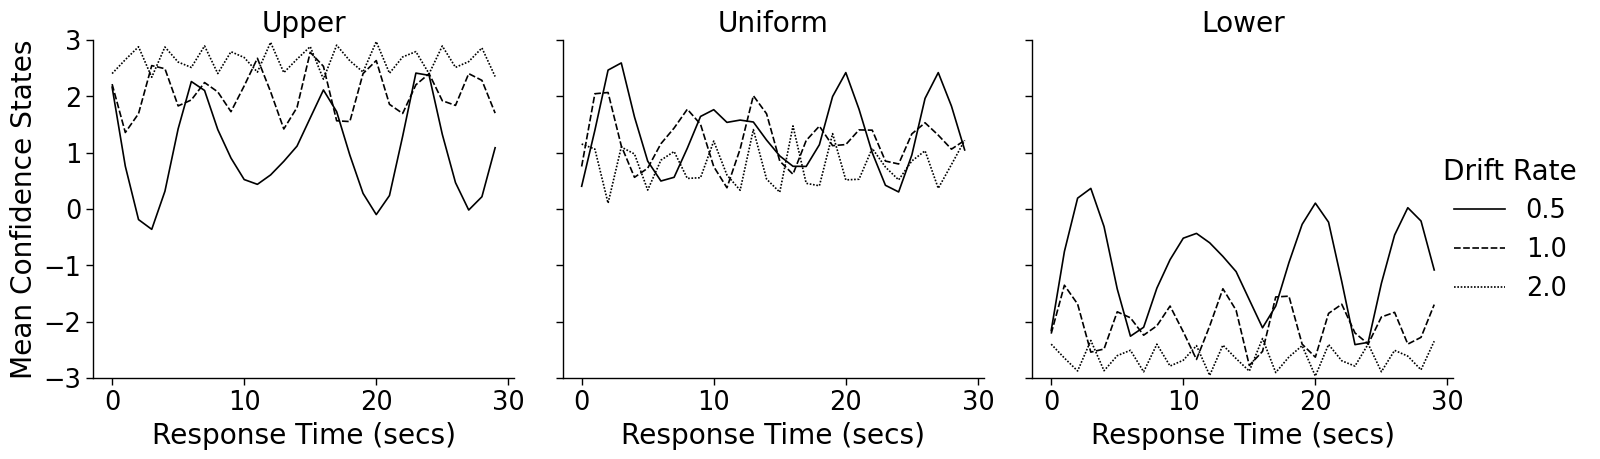

In [24]:
f = sns.relplot(df_quantum1_plot,
x="time", y="value", col="prior", style="mu", kind="line", color="Black", facet_kws={"ylim":(-(n_states//2), (n_states//2))})#, palette="Greys")
f.legend.set_title("Drift Rate")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Mean Confidence States")
f.set_titles("{col_name}")